# Statistics for WLASL: Unprocessed

In [2]:
import json
from pathlib import Path
from typing import cast, List, TypedDict
import matplotlib.pyplot as plt
import numpy as np
#locals
from configs import WLASL_ROOT, SPLIT_DIR, CLASSES_PATH
from video_dataset import get_wlasl_info
import stats2 as stats
import preprocess as preproc
from statistics import median, mean, median_high, median_low

## From the WLASL GitHUB page

Data Description
-----------------

* `gloss`: *str*, data file is structured/categorised based on sign gloss, or namely, labels.

* `bbox`: *[int]*, bounding box detected using YOLOv3 of (xmin, ymin, xmax, ymax) convention. Following OpenCV convention, (0, 0) is the up-left corner.

* `fps`: *int*, frame rate (=25) used to decode the video as in the paper.

* `frame_start`: *int*, the starting frame of the gloss in the video (decoding
with FPS=25), *indexed from 1*.

* `frame_end`: *int*, the ending frame of the gloss in the video (decoding with FPS=25). -1 indicates the gloss ends at the last frame of the video.

* `instance_id`: *int*, id of the instance in the same class/gloss.

* `signer_id`: *int*, id of the signer.

* `source`: *str*, a string identifier for the source site.

* `split`: *str*, indicates sample belongs to which subset.

* `url`: *str*, used for video downloading.

* `variation_id`: *int*, id for dialect (indexed from 0).

* `video_id`: *str*, a unique video identifier.


### Additional info:

* The videos come pre-cut from the original youtube videos, therefore, the video_id is essentially a unique identifier for each instance

* There are some issues with the labelling, especially where certain frame start and ends are way too high


### Naming convention:
For the naming of different functions, 'set' and 'split' can somtimes be used interchangibly to mean different things, which can be confusing. So for all code written by me,
* **SPLIT**: A split of WLASL, one of asl100, asl300, asl1000 and asl2000
* **SET**: A subset of a given wlasl split, one of train, val test


# TODO:
- make a flag to control preprocessed vs unprocessed
- add removed instances
- add bounding box and frame size info 

## Split

#### Pick split

In [3]:
split_options: List[stats.AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
print('Options:')
for i, split_name in enumerate(split_options):
    print(f'{i} : {split_name}')

Options:
0 : asl100
1 : asl300
2 : asl1000
3 : asl2000


In [4]:
split_idx = 0 #change for different split
split_name: stats.AVAIL_SPLITS = split_options.pop(split_idx)
print(f'Selected: {split_name}')

Selected: asl100


In [5]:
split_dir = Path(WLASL_ROOT) / SPLIT_DIR
current_split = json.load(open(split_dir / f'{split_name}.json'))
classes = json.load(open(CLASSES_PATH))

acc = 0
for glossd in current_split:
    acc += len(glossd['instances'])
    
set_size = sum([len(glossd['instances']) for glossd in current_split])
print(set_size)


2038


## Set

In [6]:
set_options: List[stats.AVAIL_SETS] = ['train', 'test', 'val']
print('Options:')
for i, set_name in enumerate(set_options):
    print(f'{i} : {set_name}')

Options:
0 : train
1 : test
2 : val


#### Pick set

In [7]:
set_idx = 0
set_name: stats.AVAIL_SETS = set_options.pop(set_idx)
print(f'Selected: {set_name}')

Selected: train


In [8]:
cast(List[stats.wlasl_class_dict], current_split)
seperated = stats.seperate_by_set(current_split)
current_set = seperated[set_name]
# print(seperated.keys())

acc = 0
for key, value in seperated.items():
    subset_size = sum([len(glossd['instances']) for glossd in value])
    print(f"{key} : Size: {subset_size}")
    acc += subset_size
    
print(acc == set_size)


train : Size: 1442
val : Size: 338
test : Size: 258
True


In [9]:
ex_sample = current_set[0]
print(f'gloss: {ex_sample["gloss"]}')
print(f'Num instances: {len(ex_sample["instances"])}')

gloss: book
Num instances: 30


In [10]:
LABEL_SUFFIX = "instances_fixed_frange_bboxes_len.json"
preproc_path = Path(f'./preprocessed/labels_new/{split_name}/{set_name}_{LABEL_SUFFIX}')

assert preproc_path.exists(), f'File not found: {preproc_path}'

current_preproc_set = json.load(open(preproc_path, 'r'))
print(current_preproc_set[0])

{'bbox': [54, 23, 201, 255], 'frame_end': 64, 'frame_start': 1, 'instance_id': 0, 'signer_id': 118, 'source': 'aslbrick', 'split': 'train', 'url': 'http://aslbricks.org/New/ASL-Videos/book.mp4', 'variation_id': 0, 'video_id': '69241', 'label_num': 0, 'label_name': 'book'}


In [ ]:
from utils import cv_load
from typing import Tuple
from preprocess import instance_dict
from configs import RAW_DIR

def _retrieve_frame_shape(raw_path : Path, instance: instance_dict) -> Tuple[int, int]:
	"""Get the frame shape of a video

	Args:
		raw_path (Path): Path to raw videos directory
		instance (instance_dict): Dictionary containing key: video_id

	Returns:
		Tuple[int, int]: Width, Height
	"""
	vid_path = raw_path / (instance["video_id"] + ".mp4")

	frames = cv_load(vid_path, 0, 1)
	return frames.shape[2], frames.shape[1]
 
_retrieve_frame_shape(Path(WLASL_ROOT) / RAW_DIR,current_preproc_set[0] )

(256, 256)

In [12]:
class preproc_class_dict(TypedDict):
    """Represents a single gloss and its associated instances. Keeps the original
    unprocessed wlasl format, but with the preprocessed dict (added info)
    
    Keys
    --------
    - gloss: str
    - instances: List[InstanceDict]
    
    """
    gloss: str
    instances: List[preproc.InstanceDict]



def reverse_preproc_format(
    preproc_instances: List[preproc.InstanceDict]) -> List[preproc_class_dict]:
    num_classes = len(set([inst['label_name'] for inst in preproc_instances]))
    lst_ppcd = [preproc_class_dict(gloss='empty', instances=[])] * num_classes
    for pp_inst in preproc_instances:
        label_num = pp_inst['label_num']
        entry = lst_ppcd[label_num]
        if entry['gloss'] == 'empty':
            lst_ppcd[label_num] = preproc_class_dict(gloss=pp_inst['label_name'], instances=[pp_inst])
        else:
            lst_ppcd[label_num]['instances'].append(pp_inst)
    
    return lst_ppcd
     

In [13]:
cur_set = reverse_preproc_format(preproc_instances=current_preproc_set)
ex_sample = cur_set[0]
print(f'gloss: {ex_sample["gloss"]}')
print(f'Num instances: {len(ex_sample["instances"])}')

gloss: book
Num instances: 29


## Stats

In [14]:
figsize = (8, 5)
bins = 20

#### Example

In [15]:
ex_idx = 0
ex_gloss = current_set[ex_idx]
print(f"Gloss label: {ex_gloss['gloss']}")

Gloss label: book


In [16]:
ex_gloss_stats = stats.collect_class_stats(ex_gloss['instances'])
print('Available keys: ')
for key in ex_gloss_stats:
    print(f'- {key}')

Available keys: 
- num_instances
- length_distribution
- signers_distribution
- source_distribution
- url_distribution
- variation_distribution


Number of videos:

In [17]:
print(f"Num instances: {ex_gloss_stats['num_instances']}")

Num instances: 30


Length distribution: 

In [18]:
def plot_distribution(
    histogram: stats.HistoGram,
    gloss: str,
    set_name: stats.AVAIL_SETS,
    split_name: stats.AVAIL_SPLITS,
    metric: str,
    unit: str = "",
    categorical: bool = False) -> None:
    
    sorted_items = sorted(histogram.items(), key=lambda x: str(x[0]) if categorical else x[0])    
    # sorted_items = sorted(histogram.items(), key=lambda x: x[0]) #sort by keys
    values, counts = zip(*sorted_items) #seperate tuples
    expanded_values = [value for value, count in sorted_items for _ in range(count) ] #un-do binning 
    
    
    plt.figure(figsize=(12, 4))
    
    if categorical:
        x_pos = range(len(values))
        plt.bar(x_pos, counts, width=0.8)  # gapless for quantitative, gaps for categorical
        plt.xticks(x_pos, values, rotation=45, ha='right')
    else:
        plt.bar(values, counts, width=2)
        # plt.hist(expanded_values, bins=30)
        
        statsy_listy = [
            ('mean', lambda x: np.mean(x), 'red'),
            ('median', lambda x: np.median(x), 'blue'),
            ('lower quartile', lambda x: np.percentile(x, 25), 'brown'),
            ('upper quartile', lambda x: np.percentile(x, 75), 'brown')
        ]
        for metric_name, stat_func, colour in statsy_listy:
            metric_val = stat_func(expanded_values)
            plt.axvline(metric_val, color=colour, linestyle='--', 
            label=f"{metric_name}: {metric_val:.1f}{' ' + unit if unit else ''}")
        
        
        
        plt.legend()
    
    xlabel = f"{metric}{' (' + unit + ')' if unit else ''}"
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(f'{metric.capitalize()} Distribution: {split_name} / {set_name} / "{gloss}"')
    plt.tight_layout()
    plt.show()


25


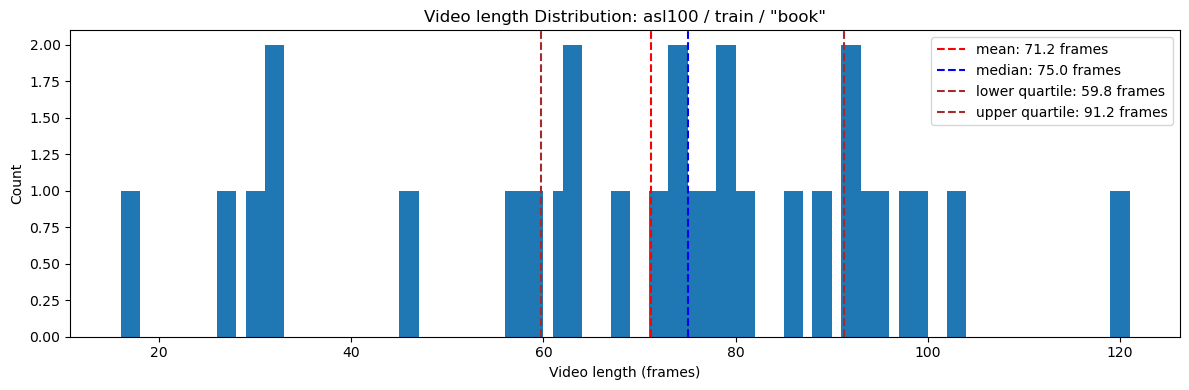

In [19]:
histogram = ex_gloss_stats['length_distribution']
print(len(histogram))
plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Video length',
    unit='frames',
    categorical=False
)

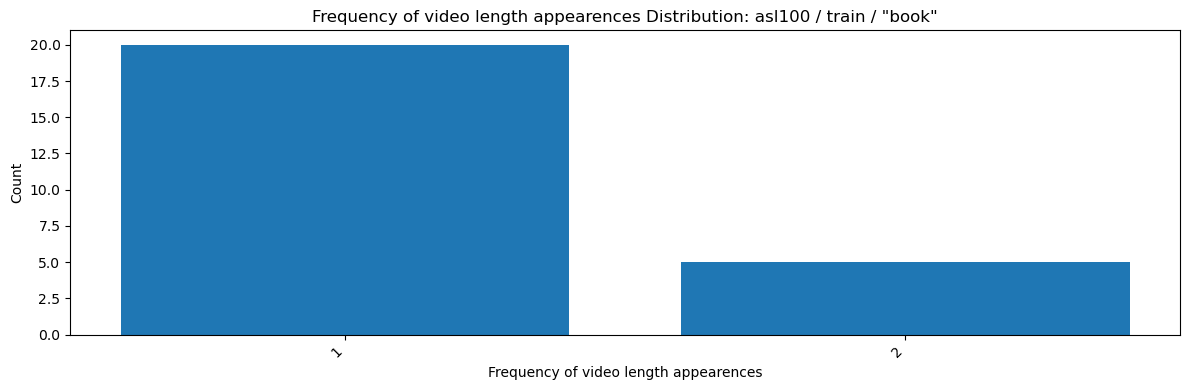

In [20]:
count_frequencies = stats.make_histogram(histogram.values())
plot_distribution(
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of video length appearences',
    categorical=True
)

Signers Distribution

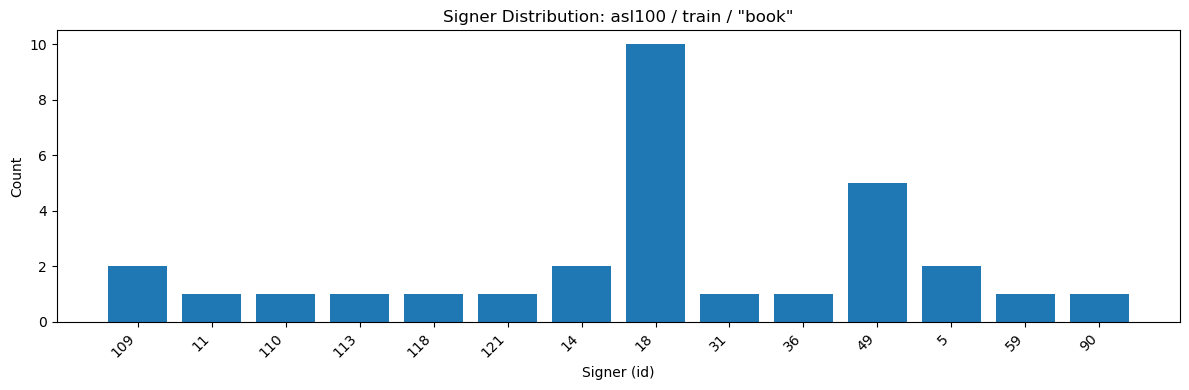

In [21]:
histogram = ex_gloss_stats['signers_distribution']
plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Signer',
    unit='id',
    categorical=True
)

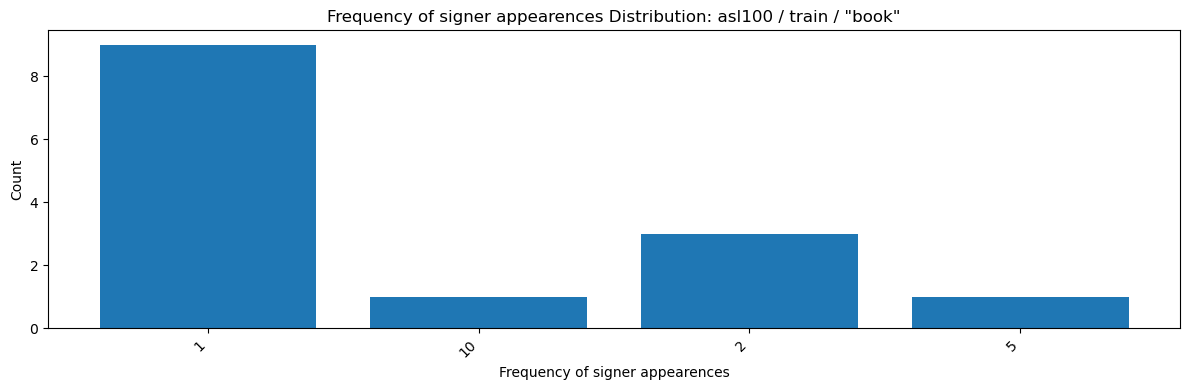

In [22]:
count_frequencies = stats.make_histogram(histogram.values())
plot_distribution(
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of signer appearences',
    categorical=True
)

Source distribution

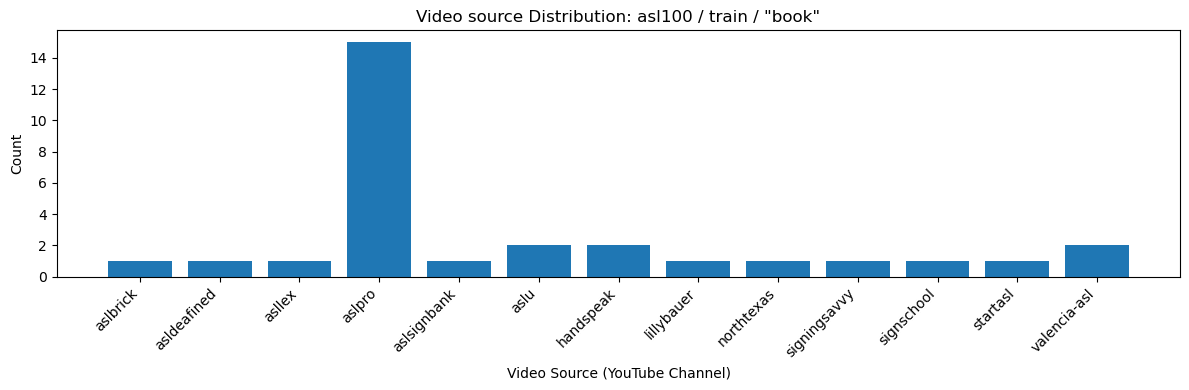

In [23]:
histogram = ex_gloss_stats['source_distribution']
plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Video Source',
    unit='YouTube Channel',
    categorical=True
)

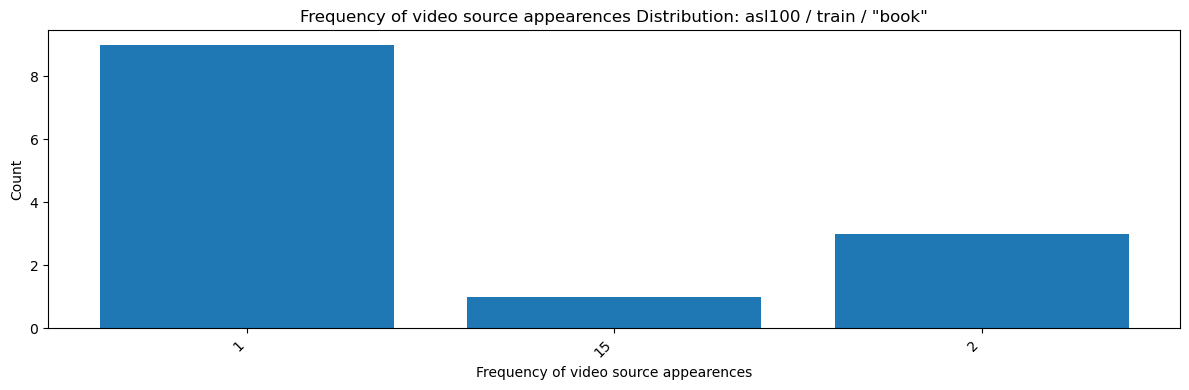

In [24]:
count_frequencies = stats.make_histogram(histogram.values())
plot_distribution(
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of video source appearences',
    categorical=True
)

URL distribution

30


/tmp/ipykernel_2748440/1989019361.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


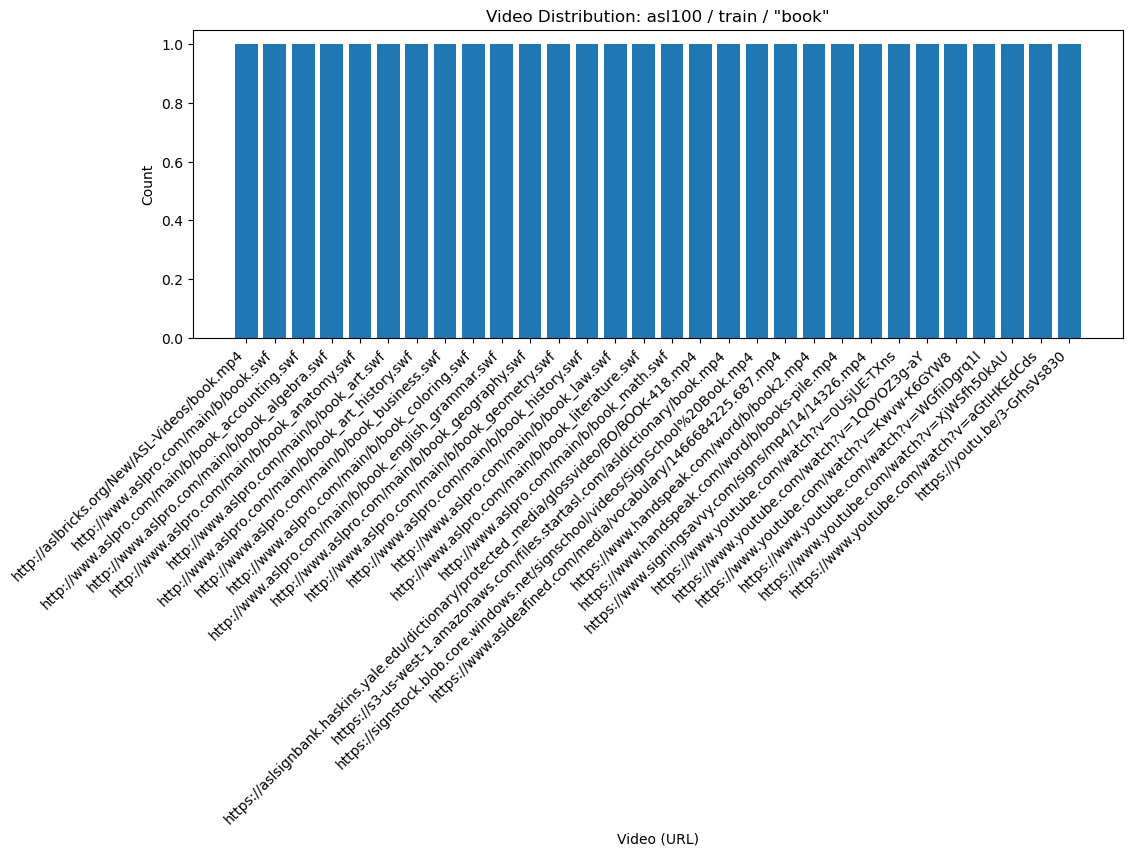

In [25]:
histogram = ex_gloss_stats['url_distribution']
print(len(histogram))
plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Video',
    unit='URL',
    categorical=True
)

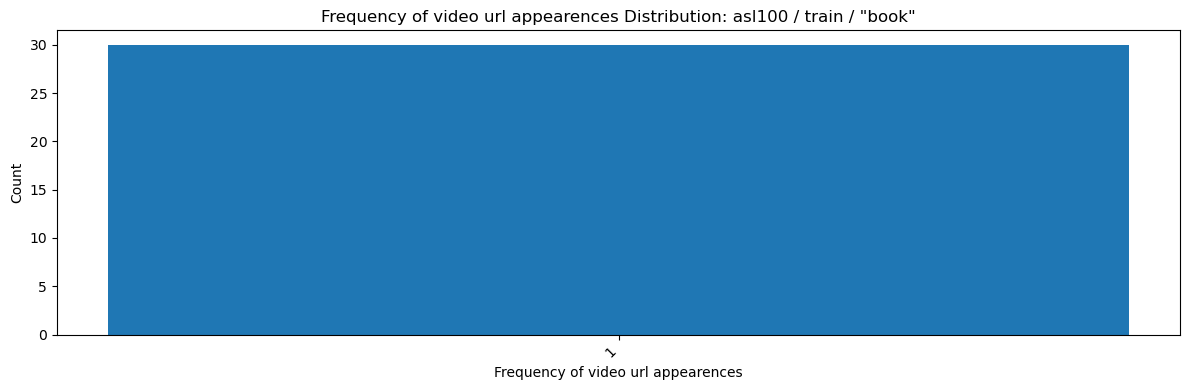

In [26]:
count_frequencies = stats.make_histogram(histogram.values())
plot_distribution(
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of video url appearences',
    categorical=True
)